In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
import pandas as pd
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, roc_auc_score
from sklearn.svm import SVC
from sklearn.semi_supervised import SelfTrainingClassifier, LabelPropagation, LabelSpreading

In [4]:
#load breast cancer dataset and split it into training and testing sets
X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [4]:
X_train.shape

(455, 30)

Choose randomly g observations in the training data as labeled. Remove the labels for the
remaining observations in the training data.

In [5]:
g = 50

indices = np.random.choice(X_train.shape[0], size=g, replace=False)
X_train_labeled = X_train[indices]
y_train_labeled = y_train[indices]

y_train_ssl = np.copy(y_train)
mask_unlabeled = np.ones(X_train.shape[0], dtype=bool)
mask_unlabeled[indices] = False
y_train_ssl[mask_unlabeled] = -1

In [8]:
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    if np.isnan(y_proba).any():
        y_proba = np.nan_to_num(y_proba, nan=0.5)

    metrics = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Balanced Accuracy': balanced_accuracy_score(y_test, y_pred),
        'F1-Measure': f1_score(y_test, y_pred, average='binary'),
        'ROC AUC': roc_auc_score(y_test, y_proba)
    }
    return metrics

In [9]:
all_results = {}

# (a) Naive Method
naive_model = SVC(kernel='rbf', probability=True, random_state=42)
naive_model.fit(X_train_labeled, y_train_labeled)
all_results['Naive Method (g=50)'] = evaluate_model(naive_model, X_test, y_test)

# (b) Self-training
base_svc = SVC(kernel='rbf', probability=True, random_state=42)
self_training_model = SelfTrainingClassifier(base_svc, max_iter=10)
self_training_model.fit(X_train, y_train_ssl)
all_results['Self-training'] = evaluate_model(self_training_model, X_test, y_test)

# (c) Label Propagation
label_prop_model = LabelPropagation(kernel='rbf', gamma=0.1)
label_prop_model.fit(X_train, y_train_ssl)
all_results['Label Propagation'] = evaluate_model(label_prop_model, X_test, y_test)

# (d) Label Spreading
label_spread_model = LabelSpreading(kernel='rbf', gamma=0.1, alpha=0.2)
label_spread_model.fit(X_train, y_train_ssl)
all_results['Label Spreading'] = evaluate_model(label_spread_model, X_test, y_test)

/usr/local/lib/python3.12/dist-packages/sklearn/semi_supervised/_label_propagation.py:231: RuntimeWarning: invalid value encountered in divide
  probabilities /= normalizer
/usr/local/lib/python3.12/dist-packages/sklearn/semi_supervised/_label_propagation.py:231: RuntimeWarning: invalid value encountered in divide
  probabilities /= normalizer
/usr/local/lib/python3.12/dist-packages/sklearn/semi_supervised/_label_propagation.py:231: RuntimeWarning: invalid value encountered in divide
  probabilities /= normalizer
/usr/local/lib/python3.12/dist-packages/sklearn/semi_supervised/_label_propagation.py:231: RuntimeWarning: invalid value encountered in divide
  probabilities /= normalizer


In [10]:
df_results = pd.DataFrame(all_results).T

print("\n=== PERFORMANCE COMPARISON ON TESTING DATA ===")
print(df_results.round(4))


=== PERFORMANCE COMPARISON ON TESTING DATA ===
                     Accuracy  Balanced Accuracy  F1-Measure  ROC AUC
Naive Method (g=50)    0.9035             0.8740      0.9281   0.9600
Self-training          0.9035             0.8790      0.9272   0.9600
Label Propagation      0.8947             0.8919      0.9155   0.9076
Label Spreading        0.8947             0.8919      0.9155   0.9028


Same thing, but analyzed for different g values

In [14]:
def generate_missing_data(g):
  indices = np.random.choice(X_train.shape[0], size=g, replace=False)
  X_train_labeled = X_train[indices]
  y_train_labeled = y_train[indices]

  y_train_ssl = np.copy(y_train)
  mask_unlabeled = np.ones(X_train.shape[0], dtype=bool)
  mask_unlabeled[indices] = False
  y_train_ssl[mask_unlabeled] = -1
  return X_train_labeled, y_train_labeled, y_train_ssl

def run_simulation(g_values):
  results = {}
  for g in g_values:
    results[g] = {}
    X_train_labeled, y_train_labeled, y_train_ssl = generate_missing_data(g)
        # (a) Naive Method
    naive_model = SVC(kernel='rbf', probability=True, random_state=42)
    naive_model.fit(X_train_labeled, y_train_labeled)
    results[g]['Naive Method'] = evaluate_model(naive_model, X_test, y_test)

    # (b) Self-training
    base_svc = SVC(kernel='rbf', probability=True, random_state=42)
    self_training_model = SelfTrainingClassifier(base_svc, max_iter=10)
    self_training_model.fit(X_train, y_train_ssl)
    results[g]['Naive Method']= evaluate_model(self_training_model, X_test, y_test)

    # (c) Label Propagation
    label_prop_model = LabelPropagation(kernel='rbf', gamma=0.1)
    label_prop_model.fit(X_train, y_train_ssl)
    results[g]['Label Propagation'] = evaluate_model(label_prop_model, X_test, y_test)

    # (d) Label Spreading
    label_spread_model = LabelSpreading(kernel='rbf', gamma=0.1, alpha=0.2)
    label_spread_model.fit(X_train, y_train_ssl)
    results[g]['Label Spreading'] = evaluate_model(label_spread_model, X_test, y_test)
  return results



In [16]:
g_values = range(19, len(X_train)-1, 50)
results = run_simulation(g_values)

/usr/local/lib/python3.12/dist-packages/sklearn/semi_supervised/_label_propagation.py:231: RuntimeWarning: invalid value encountered in divide
  probabilities /= normalizer
/usr/local/lib/python3.12/dist-packages/sklearn/semi_supervised/_label_propagation.py:231: RuntimeWarning: invalid value encountered in divide
  probabilities /= normalizer
/usr/local/lib/python3.12/dist-packages/sklearn/semi_supervised/_label_propagation.py:231: RuntimeWarning: invalid value encountered in divide
  probabilities /= normalizer
/usr/local/lib/python3.12/dist-packages/sklearn/semi_supervised/_label_propagation.py:231: RuntimeWarning: invalid value encountered in divide
  probabilities /= normalizer
/usr/local/lib/python3.12/dist-packages/sklearn/semi_supervised/_label_propagation.py:231: RuntimeWarning: invalid value encountered in divide
  probabilities /= normalizer
/usr/local/lib/python3.12/dist-packages/sklearn/semi_supervised/_label_propagation.py:231: RuntimeWarning: invalid value encountered in

=== FIRST 10 rows in table ===
     g              Model  Accuracy  Balanced Accuracy  F1-Measure   ROC AUC
0   19       Naive Method  0.912281           0.895833    0.932432  0.959987
1   19  Label Propagation  0.868421           0.880952    0.888889  0.868717
2   19    Label Spreading  0.850877           0.867063    0.872180  0.837136
3   69       Naive Method  0.903509           0.874008    0.928105  0.964616
4   69  Label Propagation  0.956140           0.945437    0.965986  0.944444
5   69    Label Spreading  0.947368           0.933532    0.959459  0.944775
6  119       Naive Method  0.912281           0.890873    0.933333  0.959987
7  119  Label Propagation  0.921053           0.907738    0.938776  0.903770
8  119    Label Spreading  0.921053           0.907738    0.938776  0.934028
9  169       Naive Method  0.912281           0.885913    0.934211  0.967262


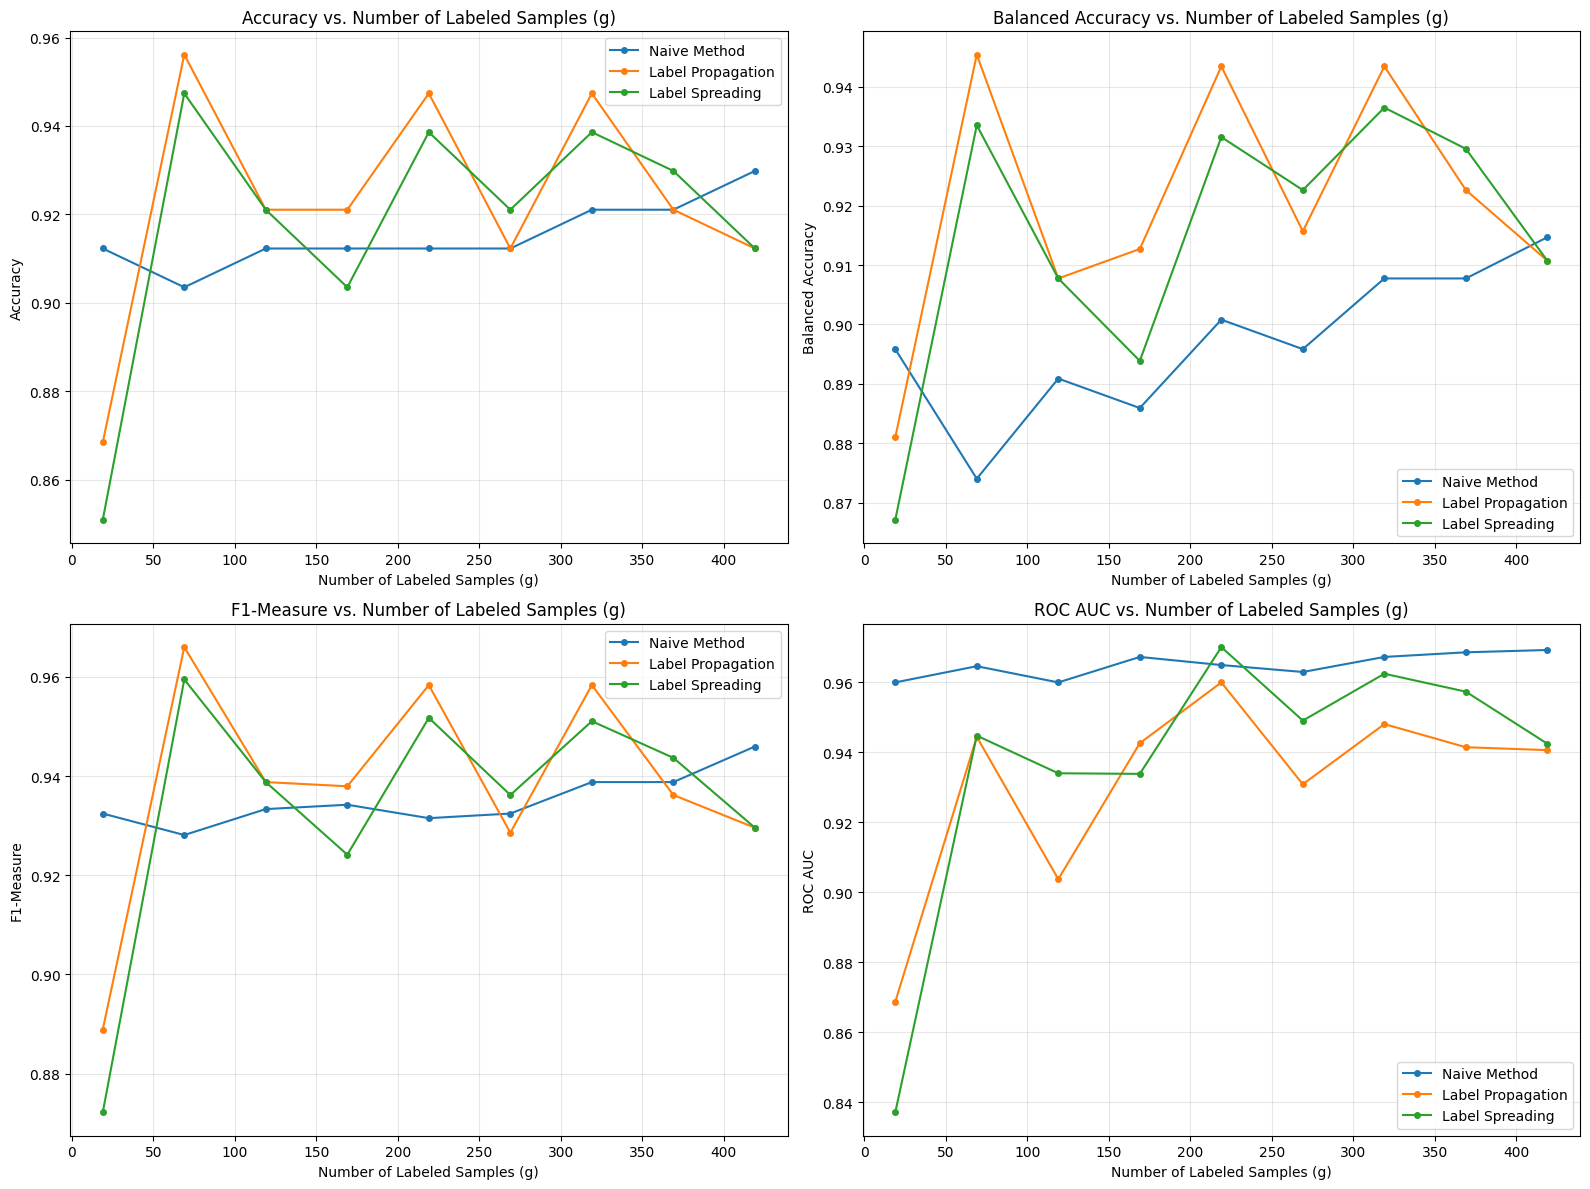

In [17]:
rows = []
for g, models in results.items():
    for model_name, metrics in models.items():
        row = {'g': g, 'Model': model_name}
        row.update(metrics)
        rows.append(row)

df_sim = pd.DataFrame(rows)

print("=== FIRST 10 rows in table ===")
print(df_sim.head(10))

metrics_to_plot = ['Accuracy', 'Balanced Accuracy', 'F1-Measure', 'ROC AUC']

plt.figure(figsize=(16, 12))

for i, metric in enumerate(metrics_to_plot, 1):
    plt.subplot(2, 2, i)

    for model_name in df_sim['Model'].unique():
        df_model = df_sim[df_sim['Model'] == model_name]
        plt.plot(df_model['g'], df_model[metric], label=model_name, marker='o', markersize=4)

    plt.title(f'{metric} vs. Number of Labeled Samples (g)')
    plt.xlabel('Number of Labeled Samples (g)')
    plt.ylabel(metric)
    plt.grid(True, alpha=0.3)
    plt.legend()

plt.tight_layout()
plt.show()